## Imports :

In [1]:
import joblib
import copy

import scipy as sp
from scipy.stats import skew, boxcox, mode
from scipy.spatial import distance
import cvxpy as cp

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import missingno as msno
from sklearn.impute import SimpleImputer 

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, ElasticNet, Lasso, RidgeCV, LassoCV, ElasticNetCV, LogisticRegression, SGDClassifier, LogisticRegressionCV, RidgeClassifier, RidgeClassifierCV
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, PowerTransformer, FunctionTransformer, QuantileTransformer, LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics
from sklearn.utils.extmath import weighted_mode
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.datasets import load_breast_cancer, make_classification, make_blobs, make_circles, load_iris, make_regression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import LinearSVC, SVC, NuSVC
from sklearn.neighbors import KDTree, BallTree, NearestNeighbors, KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import *
from sklearn.ensemble import *
from xgboost import *
from lightgbm import *
from catboost import *

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.basemap import Basemap
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from mlxtend.evaluate import bias_variance_decomp

## Load data :

In [2]:
dfN = pd.read_csv('../data/train_set_eN.csv')
dfS = pd.read_csv('../data/train_set_eS.csv')

In [3]:
x_trainN, y_trainN = np.array(dfN.iloc[:, :-1]), np.array(dfN.iloc[:, [-1]])
x_trainN.shape, y_trainN.shape

((28932, 31), (28932, 1))

In [4]:
x_trainS, y_trainS = np.array(dfS.iloc[:, :-1]), np.array(dfS.iloc[:, [-1]])
x_trainS.shape, y_trainS.shape

((28932, 31), (28932, 1))

In [5]:
df_vallN = pd.read_csv("../data/vall_set_eN.csv")
df_vallS = pd.read_csv("../data/vall_set_eS.csv")

In [6]:
x_vallN, y_vallN = np.array(df_vallN.iloc[:, :-1]), np.array(df_vallN.iloc[:, [-1]])
x_vallN.shape, y_vallN.shape

((7234, 31), (7234, 1))

In [7]:
x_vallS, y_vallS = np.array(df_vallS.iloc[:, :-1]), np.array(df_vallS.iloc[:, [-1]])
x_vallS.shape, y_vallS.shape

((7234, 31), (7234, 1))

In [8]:
df_testN = pd.read_csv("../data/test_set_eN.csv")
df_testS = pd.read_csv("../data/test_set_eS.csv")

In [9]:
x_testN, y_testN = np.array(df_testN.iloc[:, :-1]), np.array(df_testN.iloc[:, [-1]])
x_testN.shape, y_testN.shape

((9043, 31), (9043, 1))

In [10]:
x_testS, y_testS = np.array(df_testS.iloc[:, :-1]), np.array(df_testS.iloc[:, [-1]])
x_testS.shape, y_testS.shape

((9043, 31), (9043, 1))

## Train :

### Bagging with best logistic model :

In [13]:
estimator = joblib.load('F:/machin_lerning/bank_marketing/best_logistic_model')
model1 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=0.6, oob_score=True, warm_start=False, n_jobs=-1, random_state=100)
model1.fit(x_trainS, y_trainS.ravel())

C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\ensemble\_bagging.py:975: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\ensemble\_bagging.py:981: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegre...ton-cholesky')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",2
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [15]:
model1.oob_score_

0.8432531453062353

In [16]:
train_scores_, vall_scores_ = [], []
for i in np.linspace(0.1, 1, 10):
    model1 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=i, oob_score=True, warm_start=False, n_jobs=-1, random_state=100)
    model1.fit(x_trainS, y_trainS.ravel())

    train_score = model1.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model1.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\ensemble\_bagging.py:975: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\ensemble\_bagging.py:981: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\ensemble\_bagging.py:975: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\ensemble\_bagging.py:981: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]
C:\Users\Ertebatat-Sahar\anaconda3\envs\

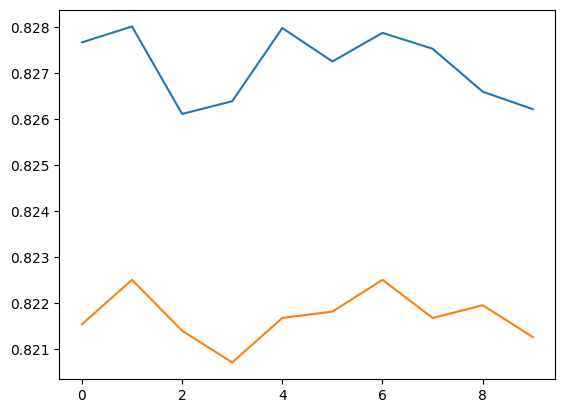

In [18]:
plt.plot(train_scores_)
plt.plot(vall_scores_)

In [27]:
train_scores_, vall_scores_ = [], []
for i in np.arange(2, 30):
    model1 = BaggingClassifier(estimator=estimator, n_estimators=i, max_samples=0.6, oob_score=False, warm_start=True, n_jobs=-1, random_state=100)
    model1.fit(x_trainS, y_trainS.ravel())

    train_score = model1.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model1.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

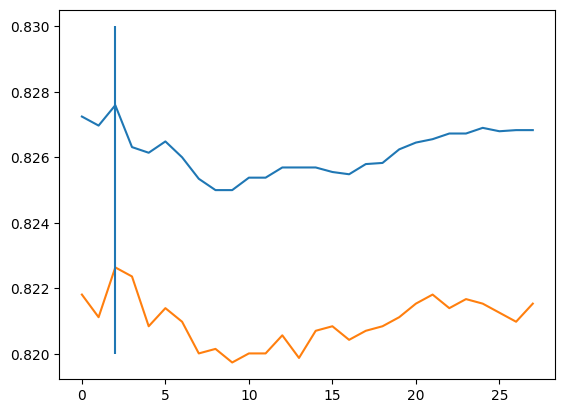

In [28]:
plt.plot(train_scores_)
plt.plot(vall_scores_)
plt.vlines(x=2, ymax=0.83, ymin=0.82)

In [29]:
model1 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=0.6, oob_score=True, warm_start=False, n_jobs=-1, random_state=100)
model1.fit(x_trainS, y_trainS.ravel())

C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\ensemble\_bagging.py:975: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\sklearn\ensemble\_bagging.py:981: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegre...ton-cholesky')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",2
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.6
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [31]:
model1.score(x_trainS, y_trainS), model1.score(x_vallS, y_vallS)

(0.8272501036914144, 0.8218136577273984)

In [81]:
tn, fp, fn, tp = metrics.confusion_matrix(y_trainS, model1.predict(x_trainS)).ravel().tolist()
tn, fp, fn, tp

(21039, 4508, 490, 2895)

In [83]:
tn, fp, fn, tp = metrics.confusion_matrix(y_vallS, model1.predict(x_vallS)).ravel().tolist()
tn, fp, fn, tp

(5217, 1171, 118, 728)

#### pasting with best logistic model :

In [45]:
model2 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=0.6, bootstrap=False, n_jobs=-1, random_state=100)
model2.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegre...ton-cholesky')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",2
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.6
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",False
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [46]:
model2.score(x_trainS, y_trainS), model2.score(x_vallS, y_vallS)

(0.8238628508226186, 0.8175283384019906)

### Bagging with best MLP model :

In [61]:
estimator = joblib.load('best_MLPnetwork')
model2 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=0.3, n_jobs=-1, random_state=100)
model2.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",MLPClassifier...dom_state=100)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",2
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.3
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [62]:
model2.score(x_trainS, y_trainS), model2.score(x_vallS, y_vallS)

(0.8989008710078805, 0.8985346972629251)

In [50]:
train_scores_, vall_scores_ = [], []
for i in np.linspace(0.1, 1, 10):
    model2 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=i,warm_start=True, n_jobs=-1, random_state=100)
    model2.fit(x_trainS, y_trainS.ravel())

    train_score = model2.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model2.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

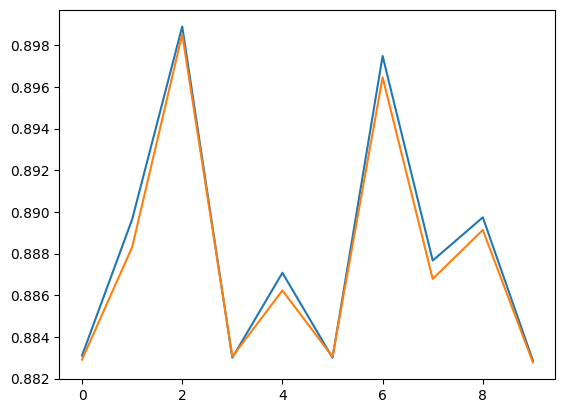

In [52]:
plt.plot(train_scores_)
plt.plot(vall_scores_)

In [63]:
train_scores_, vall_scores_ = [], []
for i in np.arange(2, 30):
    model2 = BaggingClassifier(estimator=estimator, n_estimators=i, max_samples=0.3,warm_start=True, n_jobs=-1, random_state=100)
    model2.fit(x_trainS, y_trainS.ravel())

    train_score = model2.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model2.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

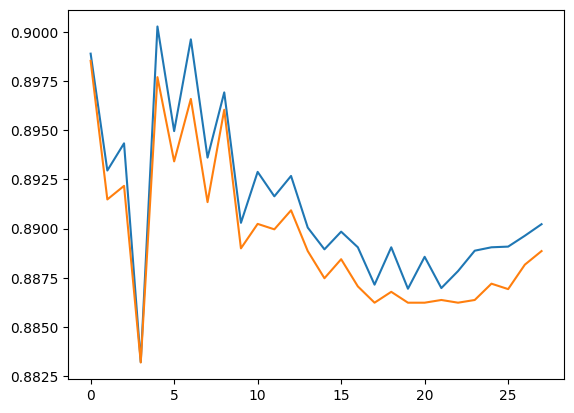

In [64]:
plt.plot(train_scores_)
plt.plot(vall_scores_)

In [73]:
model2 = BaggingClassifier(estimator=estimator, n_estimators=6, max_samples=0.3, n_jobs=-1, random_state=100)
model2.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",MLPClassifier...dom_state=100)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",6
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.3
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [74]:
model2.score(x_trainS, y_trainS), model2.score(x_vallS, y_vallS)

(0.9002834231992257, 0.8977052806192978)

In [80]:
tn_mlp, fp_mlp, fn_mlp, tp_mlp = metrics.confusion_matrix(y_trainS, model2.predict(x_trainS)).ravel().tolist()
tn_mlp, fp_mlp, fn_mlp, tp_mlp

(24985, 562, 2323, 1062)

In [79]:
tn_mlp, fp_mlp, fn_mlp, tp_mlp = metrics.confusion_matrix(y_vallS, model2.predict(x_vallS)).ravel().tolist()
tn_mlp, fp_mlp, fn_mlp, tp_mlp

(6240, 148, 592, 254)

### Bagging with best KNN model :

In [84]:
estimator = joblib.load('best_model_KNN')
model3 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=0.5, n_jobs=-1, random_state=100)
model3.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",KNeighborsCla...ts='distance')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",2
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.5
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [85]:
model3.score(x_trainS, y_trainS), model3.score(x_vallS, y_vallS)

(0.9494677174063321, 0.8916228918993642)

In [86]:
train_scores_, vall_scores_ = [], []
for i in np.linspace(0.1, 1, 10):
    model3 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=i,warm_start=True, n_jobs=-1, random_state=100)
    model3.fit(x_trainS, y_trainS.ravel())

    train_score = model3.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model3.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

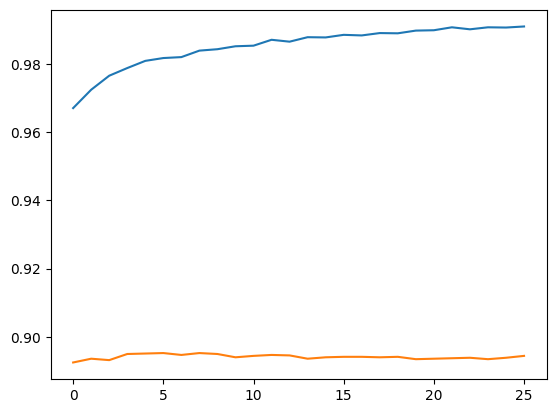

In [89]:
plt.plot(train_scores_)
plt.plot(vall_scores_)

In [90]:
model3 = BaggingClassifier(estimator=estimator, n_estimators=4, max_samples=0.8, n_jobs=-1, random_state=100)
model3.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",KNeighborsCla...ts='distance')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",4
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.8
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [91]:
model3.score(x_trainS, y_trainS), model3.score(x_vallS, y_vallS)

(0.9766003041614821, 0.8931434890793475)

In [93]:
tn_knn, fp_knn, fn_knn, tp_knn = metrics.confusion_matrix(y_trainS, model3.predict(x_trainS)).ravel().tolist()
tn_knn, fp_knn, fn_knn, tp_knn

(25473, 74, 603, 2782)

In [94]:
tn_knn_test, fp_knn_test, fn_knn_test, tp_knn_test = metrics.confusion_matrix(y_vallS, model3.predict(x_vallS)).ravel().tolist()
tn_knn_test, fp_knn_test, fn_knn_test, tp_knn_test

(6193, 195, 578, 268)

### Bagging with best logistic Model model :

In [95]:
estimator = joblib.load('best_model_LogisRegression')
model4 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=0.5, n_jobs=-1, random_state=100)
model4.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegre...ton-cholesky')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",2
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.5
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [96]:
model4.score(x_trainS, y_trainS), model4.score(x_vallS, y_vallS)

(0.8270772846674962, 0.8205695327619574)

In [97]:
train_scores_, vall_scores_ = [], []
for i in np.linspace(0.1, 1, 10):
    model4 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=i,warm_start=True, n_jobs=-1, random_state=100)
    model4.fit(x_trainS, y_trainS.ravel())

    train_score = model4.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model4.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

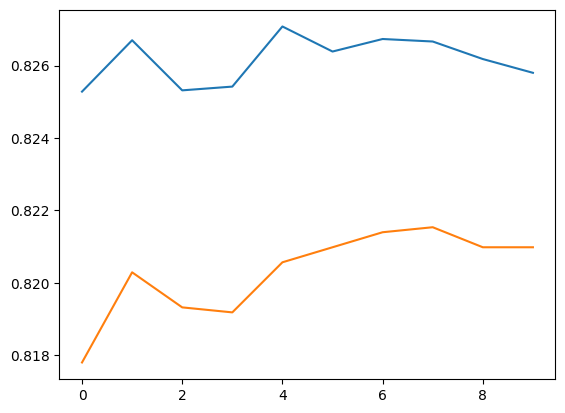

In [98]:
plt.plot(train_scores_)
plt.plot(vall_scores_)

In [101]:
train_scores_, vall_scores_ = [], []
for i in np.arange(2, 20):
    model4 = BaggingClassifier(estimator=estimator, n_estimators=i, max_samples=0.7,warm_start=True, n_jobs=-1, random_state=100)
    model4.fit(x_trainS, y_trainS.ravel())

    train_score = model4.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model4.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

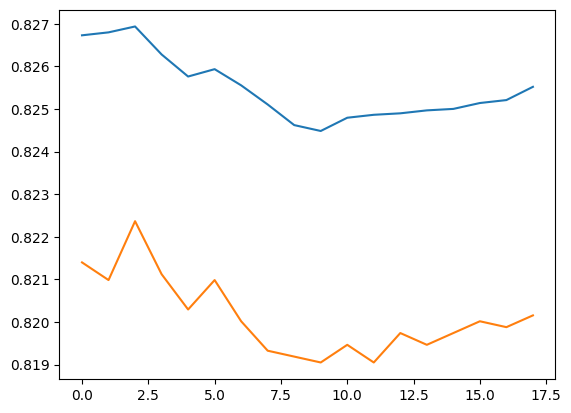

In [103]:
plt.plot(train_scores_)
plt.plot(vall_scores_)

In [104]:
model4 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=0.7, n_jobs=-1, random_state=100)
model4.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegre...ton-cholesky')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",2
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.7
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [105]:
model4.score(x_trainS, y_trainS), model4.score(x_vallS, y_vallS)

(0.8267316466196599, 0.8213989494055848)

### Bagging with best Decision tree Model model :

In [106]:
estimator = joblib.load('decision_tree')
model5 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=0.5, n_jobs=-1, random_state=100)
model5.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...dom_state=100)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",2
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.5
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [107]:
model5.score(x_trainS, y_trainS), model5.score(x_vallS, y_vallS)

(0.9321858150145168, 0.8952170306884158)

In [108]:
train_scores_, vall_scores_ = [], []
for i in np.linspace(0.1, 1, 10):
    model5 = BaggingClassifier(estimator=estimator, n_estimators=2, max_samples=i,warm_start=True, n_jobs=-1, random_state=100)
    model5.fit(x_trainS, y_trainS.ravel())

    train_score = model5.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model5.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

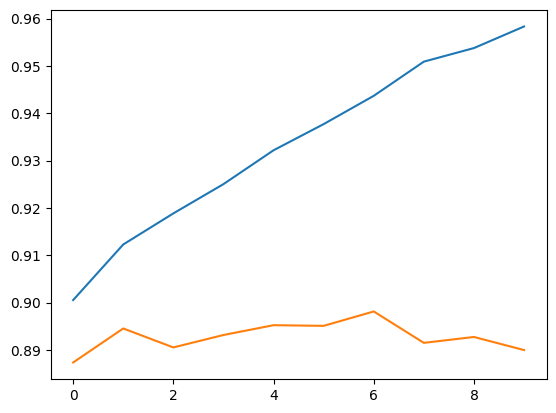

In [109]:
plt.plot(train_scores_)
plt.plot(vall_scores_)

In [110]:
train_scores_, vall_scores_ = [], []
for i in np.arange(2, 20):
    model5 = BaggingClassifier(estimator=estimator, n_estimators=i, max_samples=0.6,warm_start=True, n_jobs=-1, random_state=100)
    model5.fit(x_trainS, y_trainS.ravel())

    train_score = model5.score(x_trainS, y_trainS)
    train_scores_.append(train_score)

    vall_scores = model5.score(x_vallS, y_vallS)
    vall_scores_.append(vall_scores)

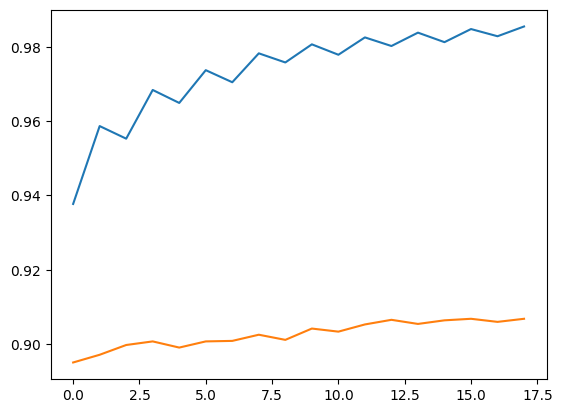

In [111]:
plt.plot(train_scores_)
plt.plot(vall_scores_)

In [118]:
model5 = BaggingClassifier(estimator=estimator, n_estimators=17, max_samples=0.6, n_jobs=-1, random_state=100)
model5.fit(x_trainS, y_trainS.ravel())

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...dom_state=100)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",17
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.6
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",100
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [119]:
model5.score(x_trainS, y_trainS), model5.score(x_vallS, y_vallS)

(0.9847573620904189, 0.9068288636991982)

In [120]:
tn, fp, fn, tp = metrics.confusion_matrix(y_trainS, model5.predict(x_trainS)).ravel().tolist()
tn, fp, fn, tp

(25441, 106, 335, 3050)

In [121]:
tn, fp, fn, tp = metrics.confusion_matrix(y_vallS, model5.predict(x_vallS)).ravel().tolist()
tn, fp, fn, tp

(6119, 269, 405, 441)

In [122]:
joblib.dump(model5, '../models/best_Bagging')

['best_Bagging']